# Разведочный Анализ данных о розничной онлайн торговле

Dataset: OnlineRetail

**Основные цели:**
- Подготовка и очистка данных
- Анализ сезонной и дневной активности заказов
- Проведение когортного анализа удержания клиентов (когорта - месяц первого заказа)

# 1. Подготовка данных к анализу

### Загрузка библиотек и датасета

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv('Online_Retail.csv', encoding='latin1')

In [34]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [35]:
df.shape

(541909, 8)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [37]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

### Очистка данных

In [38]:
df.duplicated().sum()

np.int64(5268)

In [39]:
df.drop_duplicates(inplace=True)

In [40]:
df.duplicated().sum()
df.reset_index(inplace=True, drop=True)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536641 entries, 0 to 536640
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    536641 non-null  object 
 1   StockCode    536641 non-null  object 
 2   Description  535187 non-null  object 
 3   Quantity     536641 non-null  int64  
 4   InvoiceDate  536641 non-null  object 
 5   UnitPrice    536641 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      536641 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.8+ MB


In [42]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [43]:
df.isnull().sum() / len(df) *100

InvoiceNo       0.000000
StockCode       0.000000
Description     0.270945
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     25.163377
Country         0.000000
dtype: float64

In [44]:
df.dropna(subset='CustomerID', inplace=True)

In [45]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,401604.000000,401604.000000,401604.000000
mean,12.183273,3.474064,15281.160818
std,250.283037,69.764035,1714.006089
min,-80995.000000,0.000000,12346.000000
25%,2.000000,1.250000,13939.000000
50%,5.000000,1.950000,15145.000000
75%,12.000000,3.750000,16784.000000
max,80995.000000,38970.000000,18287.000000


### Разделение данных о заказах

In [46]:
df[df['InvoiceNo'].str.startswith('C', na=False)]['InvoiceNo'].count()

np.int64(8872)

In [47]:
dfc = df[df['InvoiceNo'].str.startswith('C', na=False)].copy() #возвраты
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)] #выполненные

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 536640
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  object 
 1   StockCode    392692 non-null  object 
 2   Description  392692 non-null  object 
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  object 
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      392692 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.0+ MB


In [49]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8872 entries, 141 to 536449
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    8872 non-null   object 
 1   StockCode    8872 non-null   object 
 2   Description  8872 non-null   object 
 3   Quantity     8872 non-null   int64  
 4   InvoiceDate  8872 non-null   object 
 5   UnitPrice    8872 non-null   float64
 6   CustomerID   8872 non-null   float64
 7   Country      8872 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 623.8+ KB


In [50]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


### Разделение даты на день, месяц, год и час. Сумма заказа

In [87]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df.sort_values('InvoiceDate', inplace=True)

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df['WeekDay'] = df['InvoiceDate'].dt.day_name()
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
df['MonthName'] = df['InvoiceDate'].dt.month_name()
df['Year'] = df['InvoiceDate'].dt.year
df['Hour'] = df['InvoiceDate'].dt.hour

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,WeekDay,YearMonth,MonthName,Year,Hour,FirstOrder,CohortPeriod,CohortMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,Wednesday,2010-12,December,2010,8,2010-12-01 08:26:00,0,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Wednesday,2010-12,December,2010,8,2010-12-01 08:26:00,0,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,Wednesday,2010-12,December,2010,8,2010-12-01 08:26:00,0,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Wednesday,2010-12,December,2010,8,2010-12-01 08:26:00,0,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Wednesday,2010-12,December,2010,8,2010-12-01 08:26:00,0,2010-12


# 2. Анализ количества заказов и выручки

### Выручка с заказов и количество заказов по месяцам

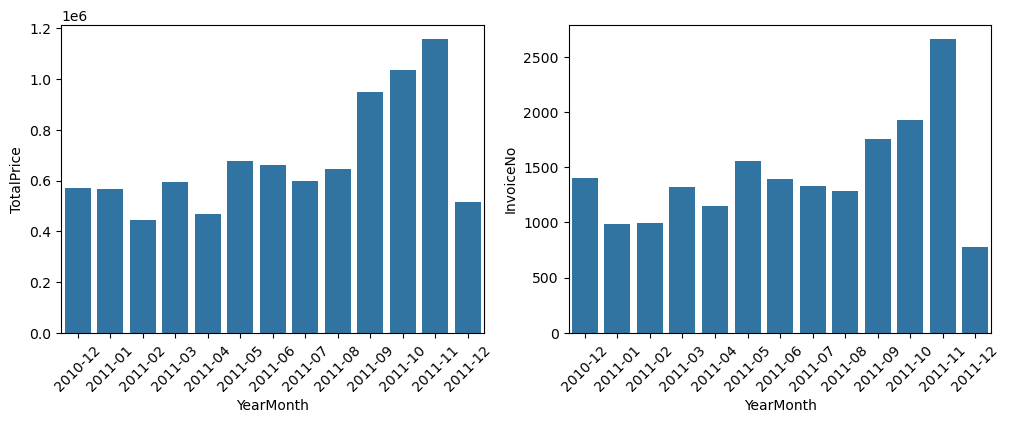

In [52]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

monthly_sales = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()
sns.barplot(data=monthly_sales, x='YearMonth', y='TotalPrice', ax=axes[0])

monthly_orders = df.groupby('YearMonth')['InvoiceNo'].nunique().reset_index()
sns.barplot(data=monthly_orders, x='YearMonth', y='InvoiceNo', ax=axes[1])

axes[0].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='x', rotation=45)

plt.show()

### Выручка с заказов и количество заказов по дням недели

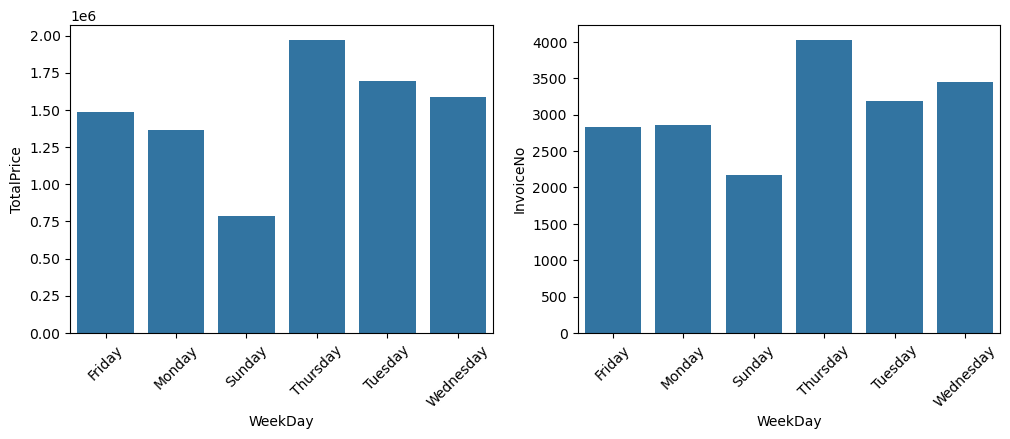

In [53]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

daily_sales = df.groupby('WeekDay')['TotalPrice'].sum().reset_index()
sns.barplot(data=daily_sales, x='WeekDay', y='TotalPrice', ax=axes[0])

daily_orders = df.groupby('WeekDay')['InvoiceNo'].nunique().reset_index()
sns.barplot(data=daily_orders, x='WeekDay', y='InvoiceNo', ax=axes[1])

axes[0].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='x', rotation=45)

plt.show()

### Количество заказов по времени дня

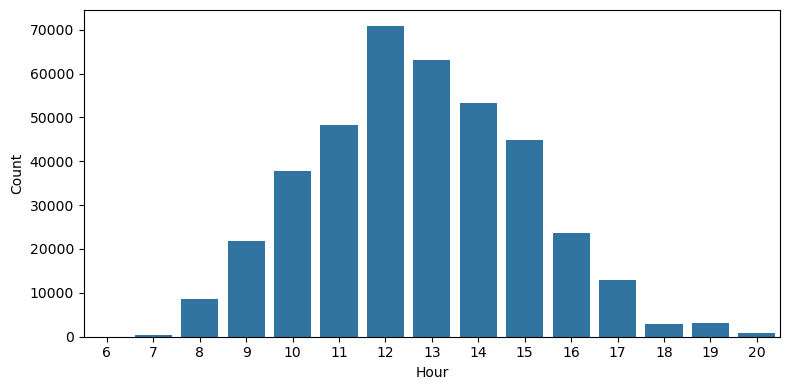

In [54]:
plt.figure(figsize=(8, 4))
count_per_hour = df['Hour'].value_counts().sort_index().reset_index()
count_per_hour.columns = ['Hour', 'Count']
sns.barplot(data=count_per_hour, x='Hour', y='Count')
plt.tight_layout()
plt.show()

### Анализ активности заказов по времени в различные дни недели

100% - общее количество заказов, сделанных в конкретный день недели

In [55]:
count_per_day = df.groupby(['WeekDay', 'Hour'])['InvoiceNo'].nunique().reset_index()

count_per_day['PercentOrders'] = count_per_day.groupby('WeekDay')['InvoiceNo'].transform(lambda x: x / x.sum())

count_per_day_matrix = count_per_day.pivot_table(index='WeekDay', columns='Hour', values='PercentOrders')
count_per_day_matrix = count_per_day_matrix.fillna(0)

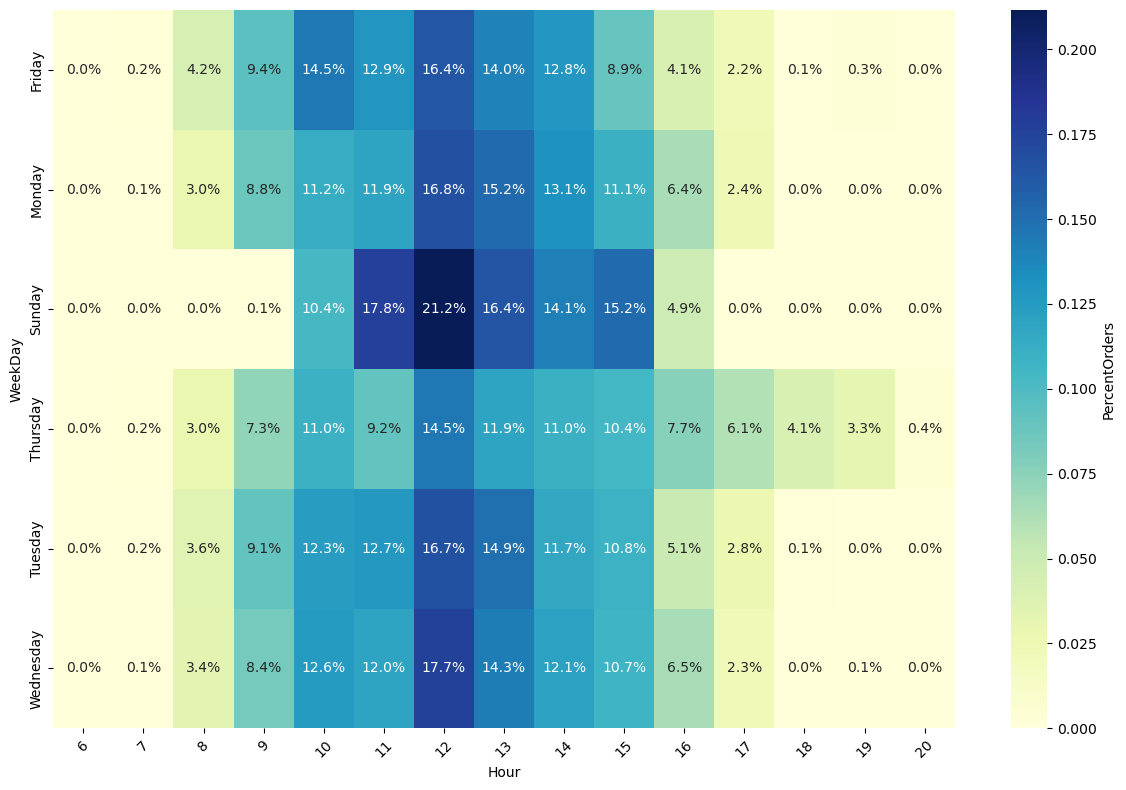

In [56]:
plt.figure(figsize=(12, 8))
sns.heatmap(count_per_day_matrix, annot=True, fmt='.1%', cmap='YlGnBu', linewidths=0, cbar_kws={'label': 'PercentOrders'})
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Анализ активности и количества заказов для разных стран

In [57]:
country_orders_count = df.groupby(['Country', 'Hour'])['InvoiceNo'].nunique().reset_index()

country_top = country_orders_count.groupby('Country')['InvoiceNo'].sum().sort_values(ascending=False)

country_orders_count['PercentOrders'] = country_orders_count.groupby('Country')['InvoiceNo'].transform(lambda x: x / x.sum())

country_matrix = country_orders_count.pivot_table(index='Country', columns='Hour', values='PercentOrders')
country_matrix = country_matrix.fillna(0)

country_matrix_top = country_matrix.loc[country_top.head(20).index]


country_top.head(20)

Country
United Kingdom     16647
Germany              457
France               389
EIRE                 260
Belgium               98
Netherlands           94
Spain                 90
Australia             57
Portugal              57
Switzerland           51
Finland               41
Italy                 38
Norway                36
Sweden                36
Channel Islands       26
Poland                19
Japan                 19
Denmark               18
Austria               17
Cyprus                16
Name: InvoiceNo, dtype: int64

Так как Великобритания сильно преобладает в количестве заказов, на heatmap представлена активность заказов в процентах, чтобы не портить масштаб

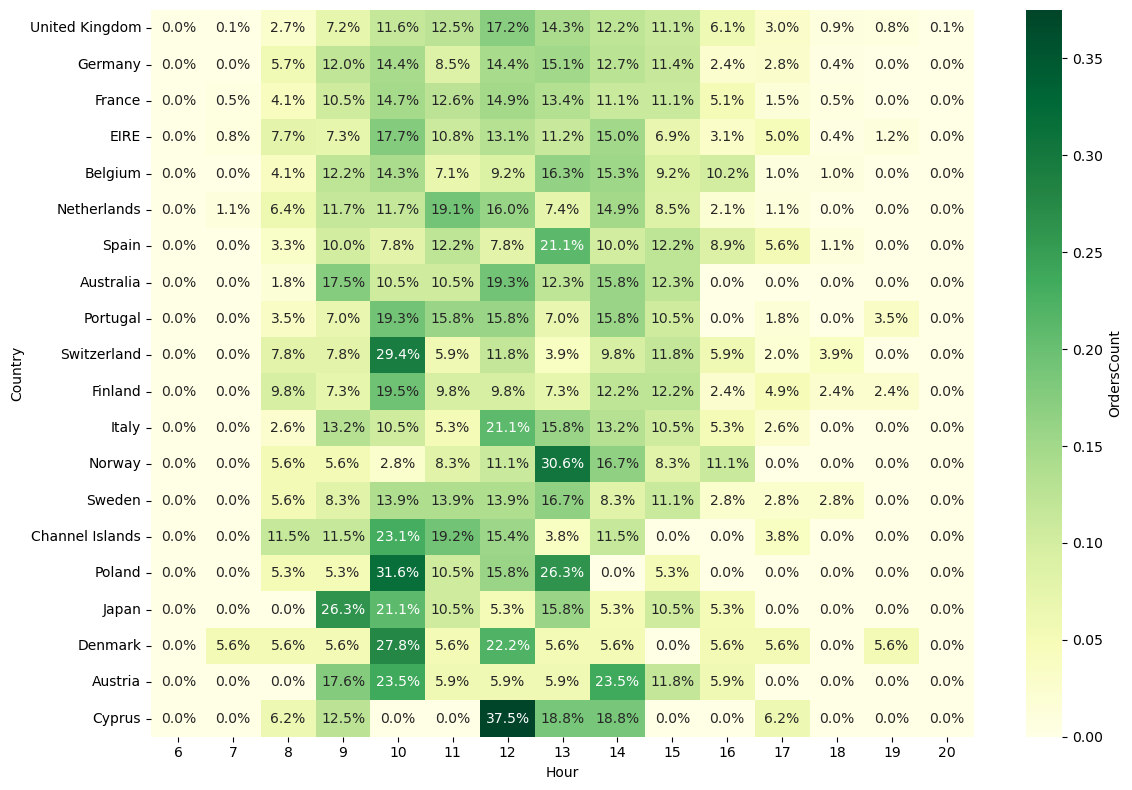

In [83]:
plt.figure(figsize=(12, 8))
sns.heatmap(country_matrix_top, annot=True, fmt ='.1%', cmap='YlGn', linewidths=0, cbar_kws={'label': 'OrdersCount'})
plt.tight_layout()

### Средний чек заказа в разных странах

<Axes: xlabel='AvgPrice', ylabel='Country'>

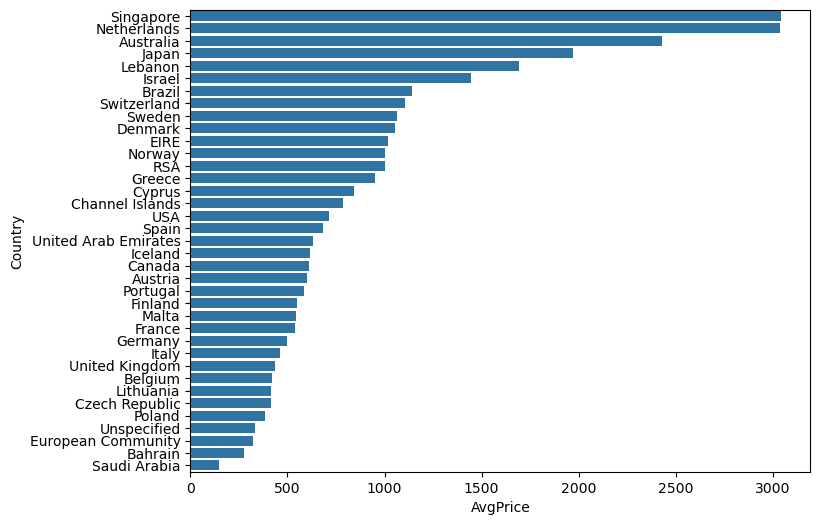

In [95]:
plt.figure(figsize=(8, 6))
total_order_price = df.groupby(['InvoiceNo','Country'])['TotalPrice'].sum().reset_index()
country_avg_price = total_order_price.groupby('Country')['TotalPrice'].mean().sort_values(ascending=False).reset_index()
country_avg_price.columns = ['Country', 'AvgPrice']
sns.barplot(data=country_avg_price, x='AvgPrice', y='Country', orient='h')

# 3. Когортный анализ удержания клиентов (Retention Rate)

### Разделение покупателей на когорты по месяцу первой покупки

Вычисление периода "жизни клиента" (количество месяцев с первой покупки)

In [60]:
first_order = df.groupby('CustomerID')['InvoiceDate'].min().reset_index()
first_order.columns = ['CustomerID', 'FirstOrder']

df = df.merge(first_order, on='CustomerID')

df['CohortPeriod'] = (df['YearMonth'].dt.year - df['FirstOrder'].dt.year) * 12 + \
                     (df['YearMonth'].dt.month - df['FirstOrder'].dt.month)

df['CohortMonth'] = df['FirstOrder'].dt.to_period('M')
# df = df.drop('FirstOrder_x', axis=1)
# df = df.drop('FirstOrder_y', axis=1)

In [61]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,WeekDay,YearMonth,MonthName,Year,Hour,FirstOrder,CohortPeriod,CohortMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,Wednesday,2010-12,December,2010,8,2010-12-01 08:26:00,0,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Wednesday,2010-12,December,2010,8,2010-12-01 08:26:00,0,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,Wednesday,2010-12,December,2010,8,2010-12-01 08:26:00,0,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Wednesday,2010-12,December,2010,8,2010-12-01 08:26:00,0,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Wednesday,2010-12,December,2010,8,2010-12-01 08:26:00,0,2010-12


### Подготовка матрицы для heatmap 

RetentionRate = количество уникальных клиентов с определенным периодом / количество уникальных клиентов в когорте по первому заказу

In [62]:
retention = df.groupby(['CohortMonth', 'CohortPeriod'])['CustomerID'].nunique().reset_index()

cohort_sizes = retention[retention['CohortPeriod'] == 0][['CohortMonth', 'CustomerID']]
cohort_sizes.rename(columns={'CustomerID': 'CohortSize'}, inplace=True)

retention = retention.merge(cohort_sizes, on='CohortMonth')

retention['RetentionRate'] = retention['CustomerID'] / retention['CohortSize']

retention.sort_values('CohortMonth', ascending=True)

retention_matrix = retention.pivot_table(index='CohortMonth', columns='CohortPeriod', values='RetentionRate')
retention_matrix = retention_matrix.fillna(0)

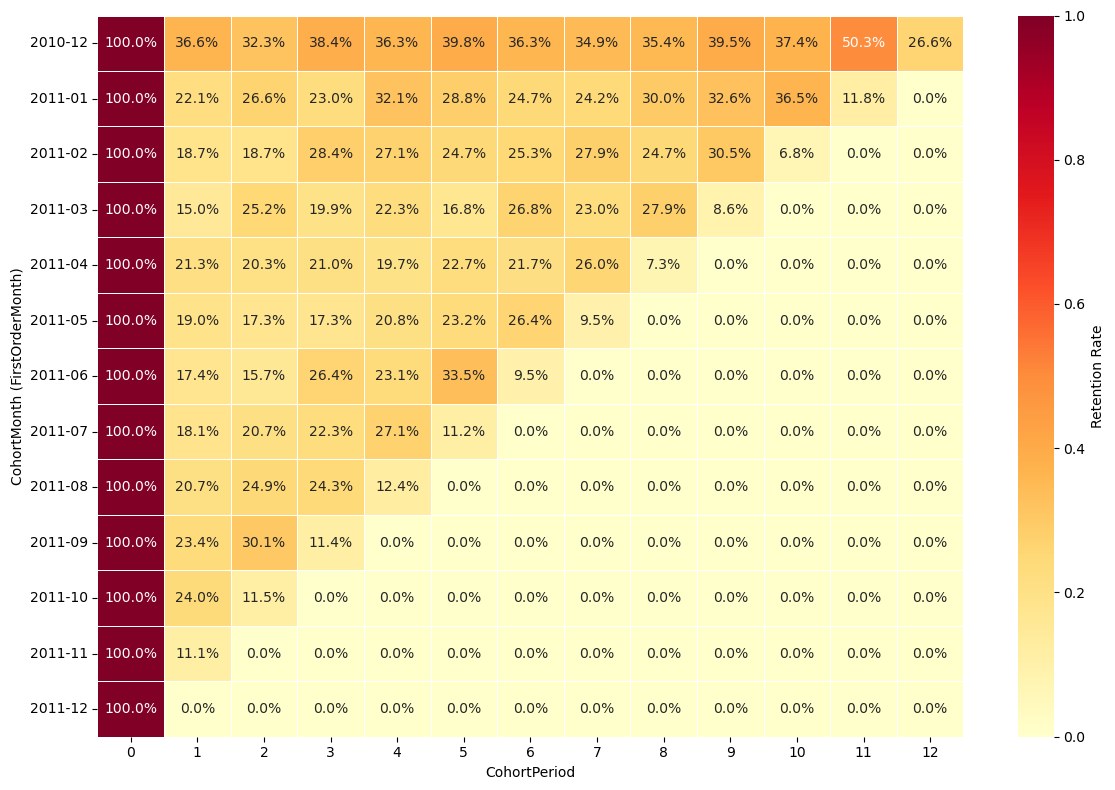

In [63]:
plt.figure(figsize=(12, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.1%', cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Retention Rate'})
plt.ylabel('CohortMonth (FirstOrderMonth)')
plt.tight_layout()

### Средний процент RetentionRate в каждой когорте

Text(0, 0.5, 'AvgRetentionRate')

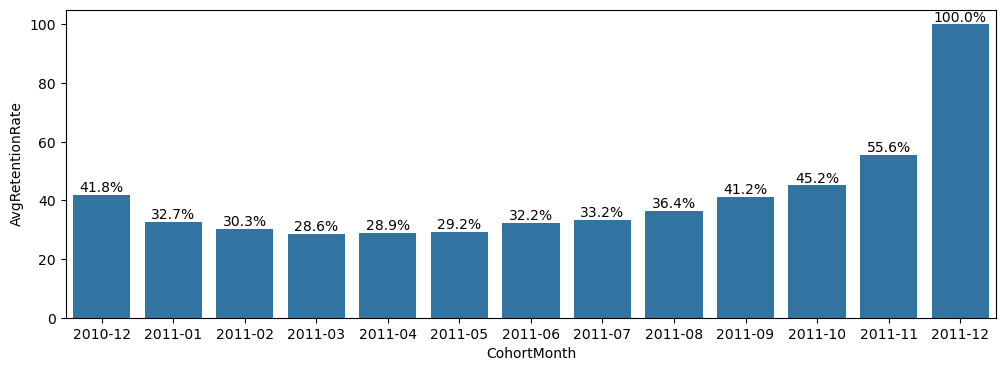

In [64]:
plt.figure(figsize=(12, 4))
avg_per_cohort = retention.groupby('CohortMonth')['RetentionRate'].mean().reset_index()
avg_per_cohort['RetentionRate'] = avg_per_cohort['RetentionRate'] * 100
ax = sns.barplot(data=avg_per_cohort, x='CohortMonth', y='RetentionRate')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge')
plt.ylabel('AvgRetentionRate')

# 4. Анализ товаров

### Анализ товаров по популярности и выручке за все время

<Axes: xlabel='TotalPrice', ylabel='Description'>

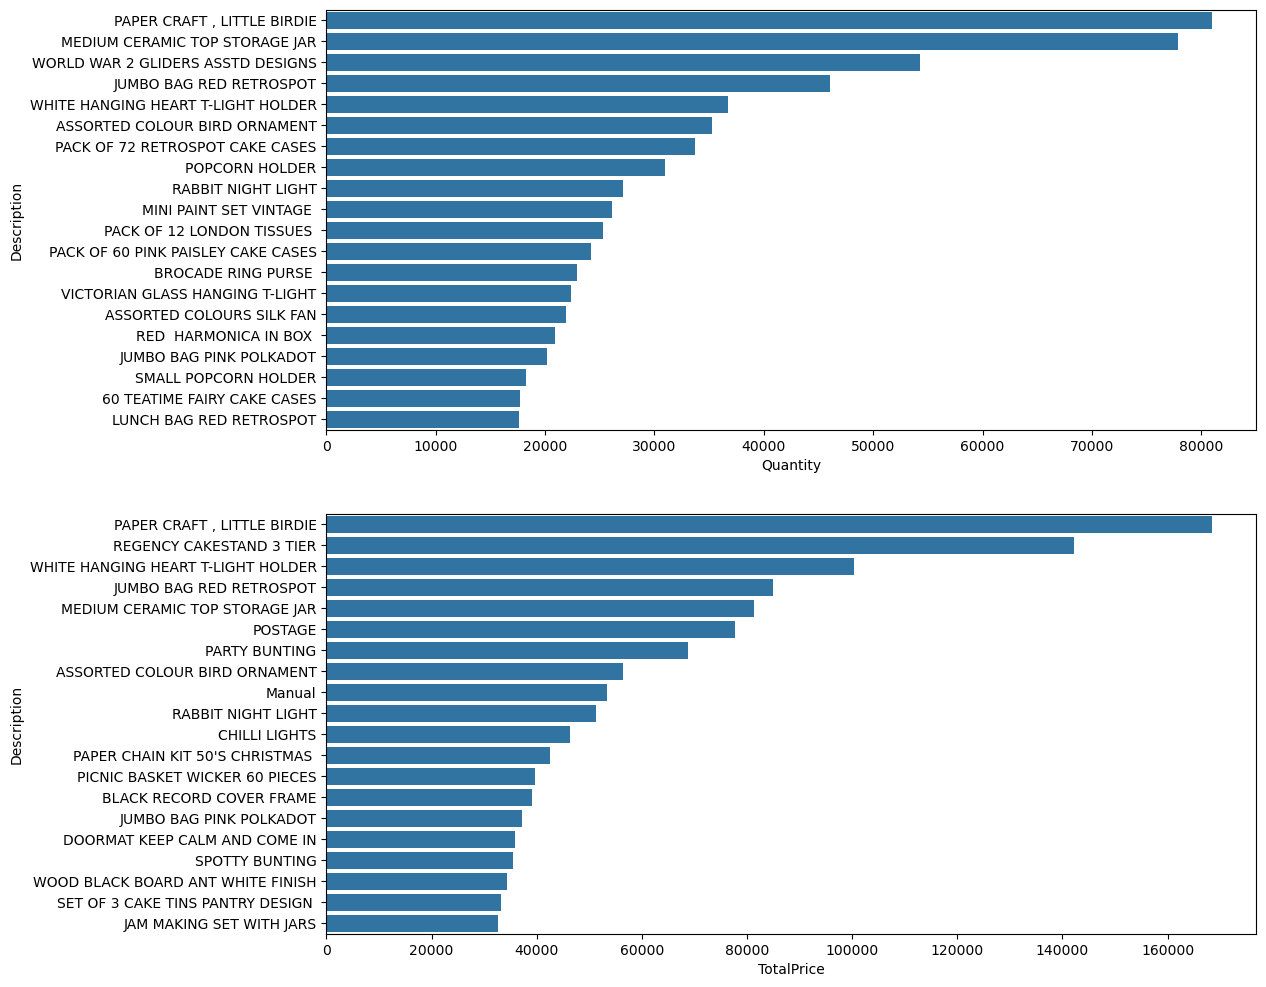

In [65]:
top_products = df.groupby(['StockCode', 'Description'])[['Quantity', 'TotalPrice']].sum()

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 12))

sns.barplot(data=top_products.sort_values('Quantity', ascending=False).head(20), x='Quantity', y='Description', orient='h', ax=axes[0])
sns.barplot(data=top_products.sort_values('TotalPrice', ascending=False).head(20), x='TotalPrice', y='Description', orient='h', ax=axes[1])

### Анализ соотношения количества и выручки для товаров

In [66]:
top_products.sort_values('Quantity', ascending=False).head()

,,Quantity,TotalPrice
StockCode,Description,,
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73
84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319,13558.41
85099B,JUMBO BAG RED RETROSPOT,46078,85040.54
85123A,WHITE HANGING HEART T-LIGHT HOLDER,36706,100392.10


<Axes: ylabel='StockCode,Description'>

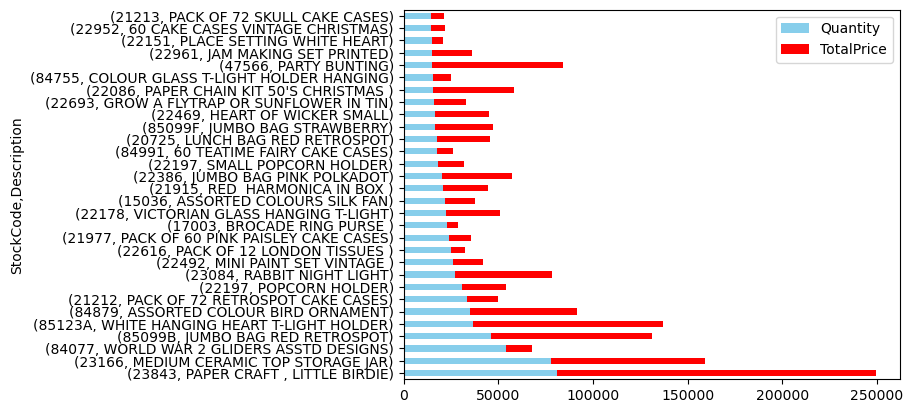

In [67]:
top_products.sort_values('Quantity', ascending=False).head(30).plot(kind='barh', color=['skyblue', 'red'], stacked=True)

### Анализ возвратов

In [68]:
dfc.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/10 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/10 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/10 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom


In [88]:
dfc['InvoiceDate'] = pd.to_datetime(dfc['InvoiceDate'], errors='coerce')
dfc.sort_values('InvoiceDate', inplace=True)

dfc['Quantity'] = abs(dfc['Quantity'])

dfc['WeekDay'] = dfc['InvoiceDate'].dt.day_name()
dfc['YearMonth'] = dfc['InvoiceDate'].dt.to_period('M')
dfc['MonthName'] = dfc['InvoiceDate'].dt.month_name()
dfc['Hour'] = dfc['InvoiceDate'].dt.hour

Количество заказов и возвратов по месяцам

<Axes: xlabel='YearMonth'>

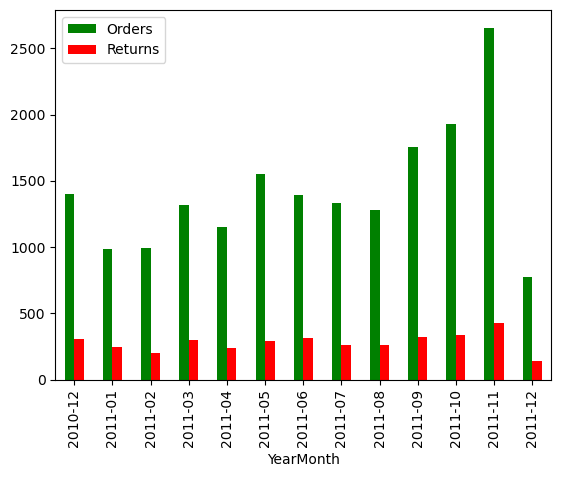

In [70]:
monthly_returns = dfc.groupby('YearMonth')['InvoiceNo'].nunique().reset_index()

monthly_orders = df.groupby('YearMonth')['InvoiceNo'].nunique().reset_index()

monthly_table = monthly_orders.merge(monthly_returns, on='YearMonth')
monthly_table.columns = ['YearMonth', 'Orders', 'Returns']

monthly_table = monthly_table.set_index('YearMonth')

monthly_table.plot(kind='bar', color=['green', 'red'])

,StockCode,Description,Quantity
0,23843,"PAPER CRAFT , LITTLE BIRDIE",80995
1,23166,MEDIUM CERAMIC TOP STORAGE JAR,74494
2,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9367
3,M,Manual,3995
4,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3150
5,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2578
6,21175,GIN + TONIC DIET METAL SIGN,2030
7,22920,HERB MARKER BASIL,1527
8,22273,FELTCRAFT DOLL MOLLY,1447
9,47566B,TEA TIME PARTY BUNTING,1424


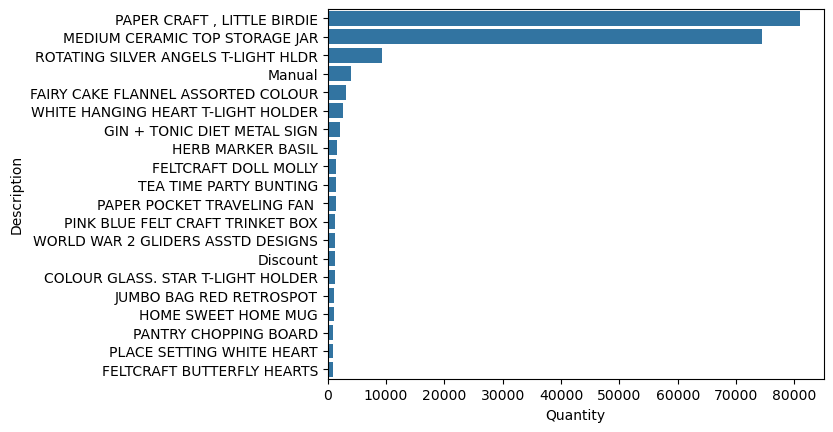

In [71]:
top_returns = dfc.groupby(['StockCode', 'Description'])['Quantity'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=top_returns.head(20), x='Quantity', y='Description', orient='h')
top_returns.head(20)